# TinyLlama Resume Training - Layers 1, 7, 14, 20, 22 - Masked Answers

This notebook builds a fresh legal QA experiment with:
- 40% sample from combined `cuad.json` + `master_clauses.csv`
- Train / validation / test split
- Zero-shot baseline on the held-out test set
- Fine-tuning TinyLlama on human layer numbers `[1, 7, 14, 20, 22]`
- Automatic resume from the latest checkpoint if training was interrupted
- PNG graphs saved in the same folder

Important:
- TinyLlama code uses zero-based indices, so these human layer numbers are mapped to `[0, 6, 13, 19, 21]`
- The notebook checks whether the trained model beats the zero-shot baseline, but no notebook can guarantee that outcome before training is run
- The notebook also checks whether training loss is lower than validation loss and prints the result

## 0. Install Dependencies

In [1]:
# Uncomment if you still need any packages in this environment
# %pip install -q transformers datasets bert-score sentencepiece accelerate tensorboard pandas matplotlib requests

## 1. Imports, GPU Check, and Experiment Config

In [2]:
import io
import json as json_module
import os
import random
import re
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
from bert_score import score as bert_score_fn
from datasets import Dataset, DatasetDict
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

MODEL_NAME = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'
SYSTEM_PROMPT = (
    'You are an expert legal contract assistant. '
    'Answer legal contract questions with meaningful legal text and keywords.'
)

RANDOM_SEED = 42
SAMPLE_FRACTION = 0.40
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
MAX_LENGTH = 256
ZERO_SHOT_SAMPLES = 30
TRAIN_EVAL_SAMPLES = 30
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16

HUMAN_LAYER_NUMBERS = [1, 7, 14, 20, 22]
ZERO_BASED_LAYERS = [layer - 1 for layer in HUMAN_LAYER_NUMBERS]
RUN_NAME = 'layers_1_7_14_20_22_masked'
OUTPUT_DIR = f'output_{RUN_NAME}'
MODEL_DIR = f'tinyllama_{RUN_NAME}'
LOG_DIR = f'tb_logs_{RUN_NAME}'
LOSS_PNG = f'{RUN_NAME}_loss.png'
COMPARE_PNG = f'{RUN_NAME}_comparison.png'
SUMMARY_PNG = f'{RUN_NAME}_summary.png'

TRAIN_JSON = f'{RUN_NAME}_train.json'
VAL_JSON = f'{RUN_NAME}_val.json'
TEST_JSON = f'{RUN_NAME}_test.json'

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU             :', torch.cuda.get_device_name(0))
    print('VRAM            :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
print('Human layers    :', HUMAN_LAYER_NUMBERS)
print('Model layers    :', ZERO_BASED_LAYERS)
print('Use bf16        :', USE_BF16)
print('Use fp16        :', USE_FP16)

d:\devatry2\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.10.0+cu126
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM            : 6.44 GB
Human layers    : [1, 7, 14, 20, 22]
Model layers    : [0, 6, 13, 19, 21]
Use bf16        : True
Use fp16        : False


## 2. Load and Build the 40% Dataset

In [3]:
def clean_text(val):
    if pd.isna(val) or str(val).strip() in ['', '[]', 'nan']:
        return None
    val = str(val).strip()
    val = re.sub(r'^\[|\]$', '', val)
    val = re.sub(r"^'+|'+$", '', val)
    return val.strip() or None

with open('cuad.json', 'r', encoding='utf-8') as f:
    cuad = json_module.load(f, strict=False)
print(f'cuad.json contracts : {len(cuad["data"])}')

CSV_URL = 'https://huggingface.co/datasets/theatticusproject/cuad/resolve/main/CUAD_v1/master_clauses.csv'
print('Downloading master_clauses.csv...')
response = requests.get(CSV_URL, timeout=60)
response.raise_for_status()
df = pd.read_csv(io.StringIO(response.text))
print(f'CSV shape           : {df.shape}')

all_examples = []

for article in cuad['data']:
    for paragraph in article['paragraphs']:
        for qa in paragraph['qas']:
            question = qa['question']
            answer = qa['answers'][0]['text'] if qa['answers'] else ''
            question = question.replace('Highlight the parts (if any) of this contract related to', '')
            question = question.replace('that should be reviewed by a lawyer.', '')
            question = re.sub(r'"[^"]*"\s*', '', question)
            question = question.replace('Details:', '').strip()
            if not answer:
                continue
            if answer.strip().lower() in ['yes', 'no']:
                continue
            if len(answer.split()) < 5:
                continue
            answer = answer[:300].strip()
            text = (
                f'<|system|>\n{SYSTEM_PROMPT}</s>\n'
                f'<|user|>\n{question}</s>\n'
                f'<|assistant|>\n{answer}</s>'
            )
            all_examples.append({
                'question': question,
                'answer': answer,
                'text': text,
                'source': 'cuad_json',
            })

CLAUSE_NAMES = [
    'Governing Law', 'Parties', 'Renewal Term',
    'Notice Period To Terminate Renewal', 'Expiration Date',
    'Effective Date', 'Agreement Date', 'Termination For Convenience',
    'Anti-Assignment', 'License Grant', 'Audit Rights',
    'Cap On Liability', 'Liquidated Damages', 'Warranty Duration',
    'Insurance', 'Ip Ownership Assignment', 'Minimum Commitment',
    'Post-Termination Services', 'Non-Compete', 'Exclusivity',
    'Change Of Control', 'Source Code Escrow',
]

csv_count = 0
for _, row in df.iterrows():
    for clause in CLAUSE_NAMES:
        clause_text = clean_text(row.get(clause))
        if clause_text is None:
            continue
        if clause_text.strip().lower() in ['yes', 'no']:
            continue
        if len(clause_text.split()) < 5:
            continue
        clause_text = clause_text[:300].strip()
        question = f'What is the {clause} clause in a legal contract?'
        text = (
            f'<|system|>\n{SYSTEM_PROMPT}</s>\n'
            f'<|user|>\n{question}</s>\n'
            f'<|assistant|>\n{clause_text}</s>'
        )
        all_examples.append({
            'question': question,
            'answer': clause_text,
            'text': text,
            'source': 'csv',
        })
        csv_count += 1

print(f'From CSV             : {csv_count}')
print(f'Total combined        : {len(all_examples)}')

random.shuffle(all_examples)
sample_size = int(len(all_examples) * SAMPLE_FRACTION)
sampled = all_examples[:sample_size]

train_end = int(sample_size * TRAIN_FRAC)
val_end = train_end + int(sample_size * VAL_FRAC)
train_examples = sampled[:train_end]
val_examples = sampled[train_end:val_end]
test_examples = sampled[val_end:]

assert len(train_examples) + len(val_examples) + len(test_examples) == sample_size

print(f'40% sample            : {sample_size}')
print(f'Train set             : {len(train_examples)}')
print(f'Validation set        : {len(val_examples)}')
print(f'Test set              : {len(test_examples)}')

Path(TRAIN_JSON).write_text(
    json_module.dumps([{'text': x['text']} for x in train_examples], ensure_ascii=False, indent=2),
    encoding='utf-8',
)
Path(VAL_JSON).write_text(
    json_module.dumps([{'text': x['text']} for x in val_examples], ensure_ascii=False, indent=2),
    encoding='utf-8',
)
Path(TEST_JSON).write_text(
    json_module.dumps([{'text': x['text']} for x in test_examples], ensure_ascii=False, indent=2),
    encoding='utf-8',
)
print(f'Saved {TRAIN_JSON}, {VAL_JSON}, and {TEST_JSON}')

cuad.json contracts : 510
CSV shape           : (510, 83)
From CSV             : 4505
Total combined        : 9833
40% sample            : 3933
Train set             : 2753
Validation set        : 589
Test set              : 591
Saved layers_1_7_14_20_22_masked_train.json, layers_1_7_14_20_22_masked_val.json, and layers_1_7_14_20_22_masked_test.json


## 3. Tokenizer and Helper Functions

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.padding_side = 'right'
print('Tokenizer loaded. Vocab size:', len(tokenizer))

def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'[^\w\s]', '', s)
    return re.sub(r'\s+', ' ', s).strip()

def token_f1(pred, gold):
    pred_tokens = normalize_answer(pred).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens or not gold_tokens:
        return float(pred_tokens == gold_tokens)
    common = set(pred_tokens) & set(gold_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def split_prompt_answer(text):
    marker = '<|assistant|>\n'
    prompt_part, answer_part = text.split(marker, 1)
    prompt_text = prompt_part + marker
    answer_text = answer_part.rsplit('</s>', 1)[0].strip()
    return prompt_text, answer_text

def tokenize_fn(example):
    prompt_text, answer_text = split_prompt_answer(example['text'])
    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )['input_ids']
    answer_ids = tokenizer(
        answer_text + tokenizer.eos_token,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )['input_ids']

    available_for_answer = MAX_LENGTH - len(prompt_ids)
    if available_for_answer <= 0:
        prompt_ids = prompt_ids[:max(1, MAX_LENGTH - 1)]
        available_for_answer = MAX_LENGTH - len(prompt_ids)

    answer_ids = answer_ids[:max(0, available_for_answer)]
    input_ids = prompt_ids + answer_ids
    attention_mask = [1] * len(input_ids)
    labels = [-100] * len(prompt_ids) + answer_ids

    pad_len = MAX_LENGTH - len(input_ids)
    if pad_len > 0:
        input_ids += [tokenizer.pad_token_id] * pad_len
        attention_mask += [0] * pad_len
        labels += [-100] * pad_len

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
    }

def ask_legal(model, question, max_new_tokens=100):
    prompt = (
        f'<|system|>\n{SYSTEM_PROMPT}</s>\n'
        f'<|user|>\n{question}</s>\n'
        f'<|assistant|>\n'
    )
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH,
    ).to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

def evaluate_model(model, examples, num_samples=30):
    model.eval()
    sample_count = min(num_samples, len(examples))
    if sample_count == 0:
        return {'num_samples': 0, 'bert_p': 0.0, 'bert_r': 0.0, 'bert_f1': 0.0, 'token_f1': 0.0, 'predictions': [], 'golds': []}
    samples = random.sample(examples, sample_count)
    predictions = [ask_legal(model, ex['question']) for ex in samples]
    golds = [ex['answer'] for ex in samples]
    precision, recall, f1 = bert_score_fn(
        predictions,
        golds,
        lang='en',
        rescale_with_baseline=False,
        verbose=False,
    )
    avg_token_f1 = sum(token_f1(p, g) for p, g in zip(predictions, golds)) / sample_count * 100
    return {
        'num_samples': sample_count,
        'bert_p': round(precision.mean().item() * 100, 2),
        'bert_r': round(recall.mean().item() * 100, 2),
        'bert_f1': round(f1.mean().item() * 100, 2),
        'token_f1': round(avg_token_f1, 2),
        'predictions': predictions,
        'golds': golds,
    }

def _sample_to_tensors(sample):
    input_ids = torch.tensor(sample['input_ids'], dtype=torch.long).unsqueeze(0)
    attention_mask = torch.tensor(sample['attention_mask'], dtype=torch.long).unsqueeze(0)
    labels = torch.tensor(sample['labels'], dtype=torch.long).unsqueeze(0)
    return input_ids, attention_mask, labels

def compute_split_loss(model, dataset_split):
    model.eval()
    total_loss = 0.0
    total_items = 0
    with torch.no_grad():
        for sample in dataset_split:
            input_ids, attention_mask, labels = _sample_to_tensors(sample)
            input_ids = input_ids.to('cuda')
            attention_mask = attention_mask.to('cuda')
            labels = labels.to('cuda')
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            total_items += 1
            del input_ids, attention_mask, labels, outputs
            torch.cuda.empty_cache()
    return 0.0 if total_items == 0 else total_loss / total_items

def compute_split_token_accuracy(model, dataset_split):
    model.eval()
    total_correct = 0
    total_tokens = 0
    with torch.no_grad():
        for sample in dataset_split:
            input_ids, attention_mask, labels = _sample_to_tensors(sample)
            input_ids = input_ids.to('cuda')
            attention_mask = attention_mask.to('cuda')
            labels = labels.to('cuda')
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            shift_logits = outputs.logits[:, :-1, :]
            shift_labels = labels[:, 1:]
            preds = torch.argmax(shift_logits, dim=-1)
            mask = shift_labels != -100
            total_correct += ((preds == shift_labels) & mask).sum().item()
            total_tokens += mask.sum().item()
            del input_ids, attention_mask, labels, outputs, shift_logits, shift_labels, preds, mask
            torch.cuda.empty_cache()
    return 0.0 if total_tokens == 0 else total_correct / total_tokens

def latest_checkpoint(output_dir):
    path = Path(output_dir)
    if not path.exists():
        return None
    checkpoints = [p for p in path.iterdir() if p.is_dir() and p.name.startswith('checkpoint-')]
    if not checkpoints:
        return None
    return str(max(checkpoints, key=lambda p: int(p.name.split('-')[-1])))


Tokenizer loaded. Vocab size: 32001


## 4. Build Hugging Face Datasets

In [5]:
dataset = DatasetDict({
    'train': Dataset.from_list([{'text': x['text']} for x in train_examples]),
    'validation': Dataset.from_list([{'text': x['text']} for x in val_examples]),
    'test': Dataset.from_list([{'text': x['text']} for x in test_examples]),
})
tokenized = dataset.map(tokenize_fn, remove_columns=['text'])
print(tokenized)

Map: 100%|██████████| 591/591 [00:00<00:00, 3299.29 examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2753
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 589
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 591
    })
})


## 5. Zero-Shot Baseline on the Test Split

In [6]:
print('Loading base model for zero-shot baseline...')
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
).to('cuda')
base_model.resize_token_embeddings(len(tokenizer))
base_model.config.use_cache = True
base_model.eval()

zero_shot_metrics = evaluate_model(base_model, test_examples, num_samples=ZERO_SHOT_SAMPLES)
ZERO_SHOT_BERT_F1 = zero_shot_metrics['bert_f1']
ZERO_SHOT_TOKEN_F1 = zero_shot_metrics['token_f1']

print(f'Zero-shot samples     : {zero_shot_metrics["num_samples"]}')
print(f'Zero-shot BERTScore F1: {ZERO_SHOT_BERT_F1}%')
print(f'Zero-shot Token F1    : {ZERO_SHOT_TOKEN_F1}%')

del base_model
torch.cuda.empty_cache()
print('Zero-shot baseline done. GPU memory cleared.')

Loading base model for zero-shot baseline...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:01<00:00, 150.70it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Ple

Zero-shot samples     : 30
Zero-shot BERTScore F1: 82.26%
Zero-shot Token F1    : 16.23%
Zero-shot baseline done. GPU memory cleared.


## 6. Fine-Tune the Requested Layers with Resume Support

In [7]:
print('Loading training model...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    low_cpu_mem_usage=True,
).to('cuda')
model.resize_token_embeddings(len(tokenizer))
model.config.use_cache = False

num_layers = model.config.num_hidden_layers
if max(ZERO_BASED_LAYERS) >= num_layers:
    raise ValueError(f'Layer index out of range for model with {num_layers} layers: {ZERO_BASED_LAYERS}')

for param in model.parameters():
    param.requires_grad = False

for idx in ZERO_BASED_LAYERS:
    for param in model.model.layers[idx].parameters():
        param.requires_grad = True

for param in model.model.norm.parameters():
    param.requires_grad = True

for param in model.lm_head.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)')

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=4,
    learning_rate=1e-4,
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    weight_decay=0.02,
    fp16=USE_FP16,
    bf16=USE_BF16,
    optim='adamw_torch',
    logging_dir=LOG_DIR,
    logging_steps=10,
    logging_strategy='steps',
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    save_total_limit=3,
    eval_accumulation_steps=1,
    prediction_loss_only=True,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    remove_unused_columns=False,
    report_to=['tensorboard'],
    seed=RANDOM_SEED,
    data_seed=RANDOM_SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    callbacks=[],
)

resume_ckpt = latest_checkpoint(OUTPUT_DIR)
if resume_ckpt:
    print(f'Resuming from latest checkpoint: {resume_ckpt}')
    train_result = trainer.train(resume_from_checkpoint=resume_ckpt)
else:
    print('No checkpoint found. Starting fresh training.')
    train_result = trainer.train()

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print(f'Training finished at step: {train_result.global_step}')
print(f'Final reported training loss: {train_result.training_loss:.4f}')
print(f'Saved model directory: {MODEL_DIR}')

Loading training model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3167.26it/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainable params: 285,761,536 / 1,100,052,480 (25.98%)
No checkpoint found. Starting fresh training.


Step,Training Loss,Validation Loss
100,1.763226,1.846563
200,1.751954,1.730848
300,1.670810,1.665152
400,1.083763,1.713962
500,1.087459,1.655661
600,1.067331,1.608411
700,0.540159,1.673356
800,0.491095,1.699230
900,0.478140,1.697074
1000,0.527675,1.680403


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.29s/it]

Training finished at step: 1380
Final reported training loss: 0.9281
Saved model directory: tinyllama_layers_1_7_14_20_22_masked


## 7. Evaluate the Trained Model and Save PNG Graphs

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

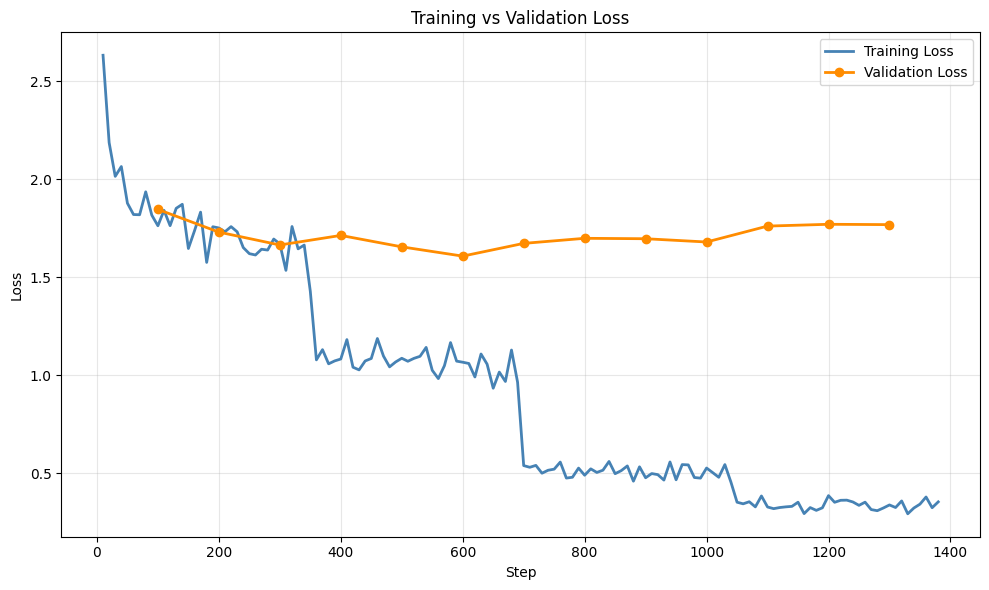

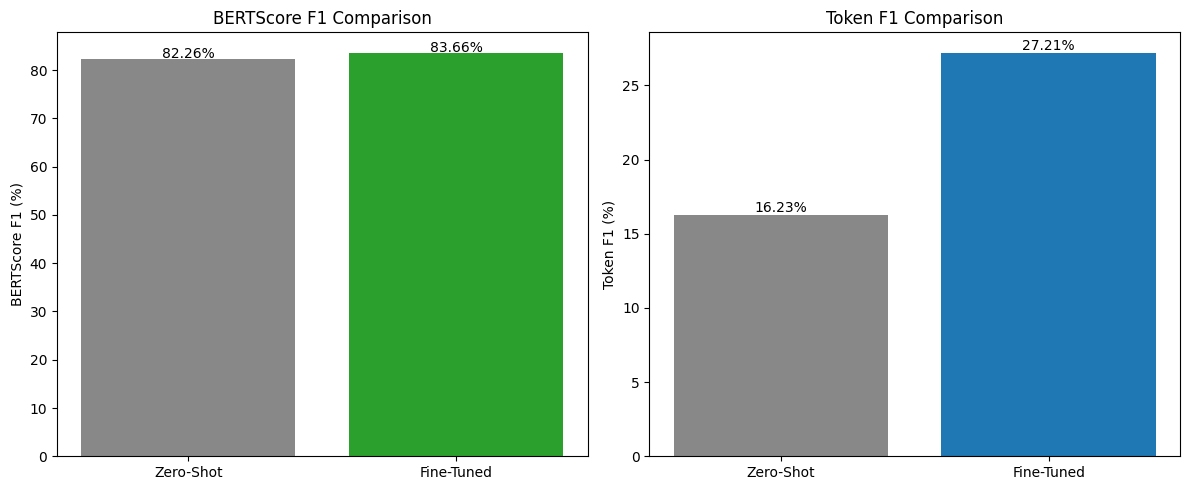

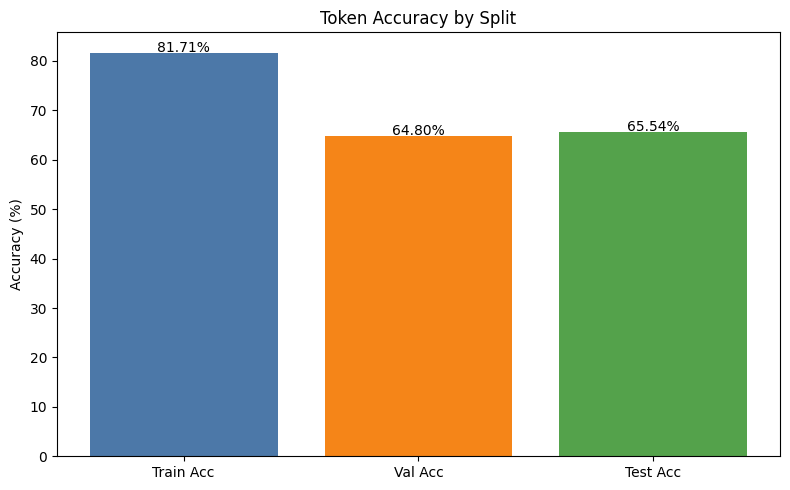

Saved PNG files:
- layers_1_7_14_20_22_masked_loss.png
- layers_1_7_14_20_22_masked_comparison.png
- layers_1_7_14_20_22_masked_summary.png

Summary:
{
  "zero_shot_bert_f1": 82.26,
  "zero_shot_token_f1": 16.23,
  "fine_tuned_bert_f1": 83.66,
  "fine_tuned_token_f1": 27.21,
  "train_token_accuracy": 81.71,
  "validation_token_accuracy": 64.8,
  "test_token_accuracy": 65.54,
  "final_train_loss": 0.35515358448028567,
  "final_validation_loss": 1.7689940929412842,
  "final_test_loss": 1.5475,
  "training_loss_below_validation_loss": true,
  "beats_zero_shot": true,
  "model_dir": "tinyllama_layers_1_7_14_20_22_masked",
  "latest_checkpoint": "output_layers_1_7_14_20_22_masked\\checkpoint-1380"
}

Fine-tuned BERTScore is higher than zero-shot.
Training loss is lower than validation loss in the saved history.


In [8]:
fine_tuned_metrics = evaluate_model(model, test_examples, num_samples=TRAIN_EVAL_SAMPLES)

train_loss_manual = compute_split_loss(model, tokenized['train'])
val_loss_manual = compute_split_loss(model, tokenized['validation'])
test_loss_manual = compute_split_loss(model, tokenized['test'])

train_token_accuracy = compute_split_token_accuracy(model, tokenized['train']) * 100
validation_token_accuracy = compute_split_token_accuracy(model, tokenized['validation']) * 100
test_token_accuracy = compute_split_token_accuracy(model, tokenized['test']) * 100

history = trainer.state.log_history
train_steps = [entry['step'] for entry in history if 'loss' in entry and 'eval_loss' not in entry]
train_losses = [entry['loss'] for entry in history if 'loss' in entry and 'eval_loss' not in entry]
eval_steps = [entry['step'] for entry in history if 'eval_loss' in entry]
eval_losses = [entry['eval_loss'] for entry in history if 'eval_loss' in entry]

final_train_loss = train_losses[-1] if train_losses else None
final_val_loss = eval_losses[-1] if eval_losses else None
loss_condition = None
if final_train_loss is not None and final_val_loss is not None:
    loss_condition = final_train_loss < final_val_loss

beats_zero_shot = fine_tuned_metrics['bert_f1'] > ZERO_SHOT_BERT_F1

summary = {
    'zero_shot_bert_f1': ZERO_SHOT_BERT_F1,
    'zero_shot_token_f1': ZERO_SHOT_TOKEN_F1,
    'fine_tuned_bert_f1': fine_tuned_metrics['bert_f1'],
    'fine_tuned_token_f1': fine_tuned_metrics['token_f1'],
    'train_token_accuracy': round(train_token_accuracy, 2),
    'validation_token_accuracy': round(validation_token_accuracy, 2),
    'test_token_accuracy': round(test_token_accuracy, 2),
    'final_train_loss': final_train_loss if final_train_loss is not None else round(train_loss_manual, 4),
    'final_validation_loss': final_val_loss if final_val_loss is not None else round(val_loss_manual, 4),
    'final_test_loss': round(test_loss_manual, 4),
    'training_loss_below_validation_loss': loss_condition,
    'beats_zero_shot': beats_zero_shot,
    'model_dir': MODEL_DIR,
    'latest_checkpoint': latest_checkpoint(OUTPUT_DIR),
}

Path(f'{RUN_NAME}_summary.json').write_text(
    json_module.dumps(summary, indent=2),
    encoding='utf-8',
)

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, label='Training Loss', linewidth=2, color='steelblue')
plt.plot(eval_steps, eval_losses, label='Validation Loss', linewidth=2, marker='o', color='darkorange')
plt.title('Training vs Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_PNG, dpi=150, bbox_inches='tight')
plt.show()

labels = ['Zero-Shot', 'Fine-Tuned']
bert_vals = [ZERO_SHOT_BERT_F1, fine_tuned_metrics['bert_f1']]
token_vals = [ZERO_SHOT_TOKEN_F1, fine_tuned_metrics['token_f1']]
x = range(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(x, bert_vals, color=['#888888', '#2ca02c' if beats_zero_shot else '#d62728'])
axes[0].set_title('BERTScore F1 Comparison')
axes[0].set_xticks(list(x), labels)
axes[0].set_ylabel('BERTScore F1 (%)')
for idx, value in enumerate(bert_vals):
    axes[0].text(idx, value + 0.2, f'{value:.2f}%', ha='center')

axes[1].bar(x, token_vals, color=['#888888', '#1f77b4'])
axes[1].set_title('Token F1 Comparison')
axes[1].set_xticks(list(x), labels)
axes[1].set_ylabel('Token F1 (%)')
for idx, value in enumerate(token_vals):
    axes[1].text(idx, value + 0.2, f'{value:.2f}%', ha='center')

plt.tight_layout()
plt.savefig(COMPARE_PNG, dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
acc_labels = ['Train Acc', 'Val Acc', 'Test Acc']
acc_vals = [
    summary['train_token_accuracy'],
    summary['validation_token_accuracy'],
    summary['test_token_accuracy'],
]
bars = ax.bar(acc_labels, acc_vals, color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_title('Token Accuracy by Split')
ax.set_ylabel('Accuracy (%)')
for bar, value in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.2, f'{value:.2f}%', ha='center')
plt.tight_layout()
plt.savefig(SUMMARY_PNG, dpi=150, bbox_inches='tight')
plt.show()

print('Saved PNG files:')
print('-', LOSS_PNG)
print('-', COMPARE_PNG)
print('-', SUMMARY_PNG)
print('\nSummary:')
print(json_module.dumps(summary, indent=2))
if beats_zero_shot:
    print('\nFine-tuned BERTScore is higher than zero-shot.')
else:
    print('\nFine-tuned BERTScore did not beat zero-shot in this run.')
if loss_condition is True:
    print('Training loss is lower than validation loss in the saved history.')
elif loss_condition is False:
    print('Training loss is not lower than validation loss in the saved history.')
else:
    print('Loss comparison unavailable because the log history is incomplete.')

In [10]:
import tensorflow as tf

print(tf.__version__)

ModuleNotFoundError: No module named 'tensorflow'